# **BurnAway AI — Developer Burnout Prediction System**


# 1. Environment Setup


In [1]:
# Standard Library Imports
import json as _json
import os
import pickle
import time
import warnings
from datetime import datetime
from pathlib import Path

# Third-Party Data Science & Utility Libraries
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

# Scikit-Learn & Imbalanced-Learn
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.metrics import CategoricalAccuracy

try:
    from google import genai
    GENAI_SDK_AVAILABLE = True
except ImportError:
    GENAI_SDK_AVAILABLE = False
    print("[INFO] google-generativeai tidak terinstall. Fallback ke requests API.")

warnings.filterwarnings("ignore")
print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")
print(f"GenAI SDK          : {'Tersedia' if GENAI_SDK_AVAILABLE else 'Tidak tersedia (pakai requests fallback)'}")


TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2
GenAI SDK          : Tersedia


# 2. Global Configuration & Hyperparameters


In [2]:
# Paths
DATA_URL         = "https://drive.google.com/uc?export=download&id=1TAJqEavYCdsi3Ry1anrt6bedkrPRcEXF"
DATASET_PATH     = "burnout_main_data.csv"
MODEL_SAVE_DIR   = Path("models")
MODEL_BEST_PATH  = MODEL_SAVE_DIR / "burnaway_model_best.keras"
MODEL_FINAL_PATH = MODEL_SAVE_DIR / "burnaway_model.keras"
API_DIR          = Path("api")
LOG_DIR          = Path("logs") / "fit" / datetime.now().strftime("%Y%m%d-%H%M%S")

# Reproducibility
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Data Configuration
TARGET_COLUMN = "burnout_level"
NUM_CLASSES   = 3
TEST_SIZE     = 0.10
VAL_SIZE      = 0.10
CLASS_LABELS  = {0: "Low", 1: "Medium", 2: "High"}
OUTLIER_COL = "commit_bug_ratio"
OUTLIER_CLIP_Q = 0.99

# Training Hyperparameters
BATCH_SIZE             = 32
EPOCHS                 = 30
LEARNING_RATE          = 1e-3
GRAD_CLIP              = 1.0
L2_REG_FACTOR          = 1e-4
MIN_EPOCHS_BEFORE_SAVE = 10

# Performance Targets
TARGET_ACCURACY = 0.85

# Model Architecture
ATTENTION_UNITS = 64
DROPOUT_RATES   = [0.15, 0.1, 0.05]

# Custom Components
LABEL_SMOOTHING = 0.05
FOCAL_GAMMA     = 0.5
FOCAL_ALPHA     = 0.25

# Generative AI Configuration
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")
GEMINI_API_KEY  = os.environ.get("GEMINI_API_KEY", "")
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/models"
GEMINI_MODEL    = "gemini-2.5-flash"

# Create output directories
for d in [MODEL_SAVE_DIR, API_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("[CONFIGURATION]")
print(f"  Dataset Path    : {DATASET_PATH}")
print(f"  Model Save Dir  : {MODEL_SAVE_DIR}")
print(f"  Batch Size      : {BATCH_SIZE}")
print(f"  Epochs          : {EPOCHS}")
print(f"  Learning Rate   : {LEARNING_RATE}")
print(f"  Target Accuracy : {TARGET_ACCURACY}")
print(f"  Random Seed     : {RANDOM_SEED}")


[CONFIGURATION]
  Dataset Path    : burnout_main_data.csv
  Model Save Dir  : models
  Batch Size      : 32
  Epochs          : 30
  Learning Rate   : 0.001
  Target Accuracy : 0.85
  Random Seed     : 42


# 3. Utility Functions


In [3]:
def set_global_seed(seed: int) -> None:
    """Set random seed for reproducibility."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def validate_dataframe(df: pd.DataFrame, required_cols: list = None, name: str = "DataFrame") -> None:
    """Validate dataframe health: empty check, null detection, required columns."""
    if df.empty:
        raise ValueError(f"[ERROR] '{name}' is empty.")

    null_counts = df.isnull().sum()
    total_nulls = int(null_counts.sum())

    print(f"\n[INFO] Validating {name}:")
    print(f"  Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"  Total Nulls: {total_nulls}", end=" ")

    if total_nulls > 0:
        print(f"\n  Null Details:")
        print(null_counts[null_counts > 0].to_string(header=False))
    else:
        print("(Clean)")

    dtype_summary = df.dtypes.value_counts().to_dict()
    print(f"  Data Types: {dtype_summary}")

    if required_cols:
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"[ERROR] Missing required columns: {missing}")

def log_metric(name: str, value: float) -> None:
    """Print metric with aligned formatting."""
    print(f"  {name:<20}: {value:.6f}")

def check_target_achieved(accuracy: float) -> str:
    """Check if target accuracy is achieved."""
    acc_status = "ACHIEVED" if accuracy >= TARGET_ACCURACY else "NOT YET"
    return f"Accuracy: {accuracy * 100:.2f}% [{acc_status}]"

def print_split_summary(X_train: np.ndarray, X_val: np.ndarray, X_test: np.ndarray) -> None:
    """Display dataset split summary table."""
    total = len(X_train) + len(X_val) + len(X_test)

    print(f"\n  {'Split':<12} {'Samples':>12} {'Percentage':>12}")
    print(f"  {'-'*38}")

    datasets = [("Train", X_train), ("Validation", X_val), ("Test", X_test)]
    for name, data in datasets:
        count = len(data)
        percent = (count / total) * 100
        print(f"  {name:<12} {count:>12} {percent:>11.1f}%")

    print(f"  {'-'*38}")
    print(f"  {'Total':<12} {total:>12} {'100.0%':>12}")

def create_tf_dataset(x_data: np.ndarray, y_data: np.ndarray, is_training: bool = True) -> tf.data.Dataset:
    """Creates a TensorFlow Dataset from numpy arrays."""
    dataset = tf.data.Dataset.from_tensor_slices((x_data.astype(np.float32), y_data.astype(np.float32)))
    if is_training:
        dataset = dataset.shuffle(buffer_size=1024, seed=RANDOM_SEED)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# Initialize
set_global_seed(RANDOM_SEED)
print("[OK] Utility functions ready.")

[OK] Utility functions ready.


# 4. Data Loading


In [4]:
def load_dataset(url: str, local_path: str) -> pd.DataFrame:
    """
    Load dataset with local caching priority.
    Downloads from URL if local file doesn't exist.
    """
    if os.path.exists(local_path):
        print(f"[INFO] Loading local dataset: {local_path}")
        df = pd.read_csv(local_path)
    else:
        print(f"[INFO] Local dataset not found. Downloading from source...")
        df = pd.read_csv(url)
        df.to_csv(local_path, index=False)
        print(f"[OK] Dataset downloaded and saved to: '{local_path}'")

    validate_dataframe(df, required_cols=[TARGET_COLUMN], name="Burnout Dataset")
    return df

# Load dataset
df_raw = load_dataset(DATA_URL, DATASET_PATH)

print(f"\n[INFO] Dataset loaded successfully")
print(f"  Shape: {df_raw.shape}")
print(f"  Columns: {list(df_raw.columns)}")


[INFO] Local dataset not found. Downloading from source...
[OK] Dataset downloaded and saved to: 'burnout_main_data.csv'

[INFO] Validating Burnout Dataset:
  Dimensions: 7000 rows, 16 columns
  Total Nulls: 0 (Clean)
  Data Types: {dtype('float64'): 14, dtype('int64'): 2}

[INFO] Dataset loaded successfully
  Shape: (7000, 16)
  Columns: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level', 'burnout_level', 'work_sleep_ratio', 'screen_time_intensity', 'commit_bug_ratio', 'work_category']


# 5. Exploratory Data Analysis (EDA)


[DATA STRUCTURE]
               Column    Type
                  age float64
     experience_years float64
     daily_work_hours float64
          sleep_hours float64
      caffeine_intake float64
         bugs_per_day float64
      commits_per_day float64
     meetings_per_day float64
          screen_time float64
       exercise_hours float64
         stress_level float64
        burnout_level   int64
     work_sleep_ratio float64
screen_time_intensity float64
     commit_bug_ratio float64
        work_category   int64

[TARGET DISTRIBUTION] 'burnout_level':
  Low       :  1593 (22.76%)
  Medium    :  3625 (51.79%)
  High      :  1782 (25.46%)


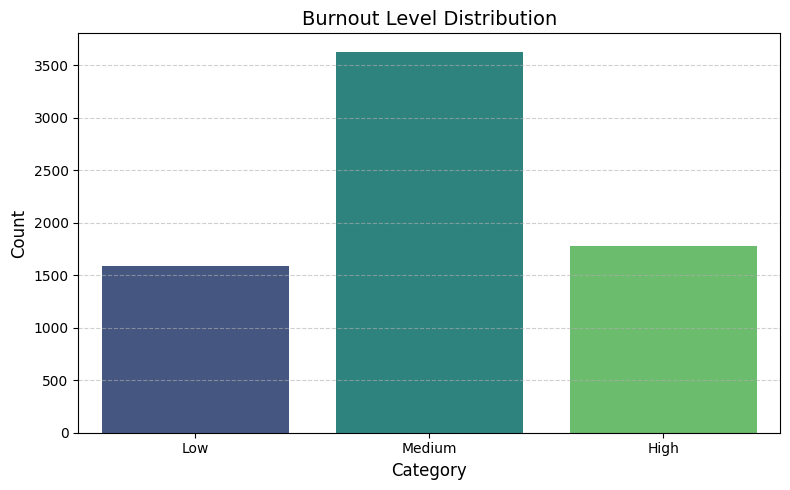


[DESCRIPTIVE STATISTICS]
                        count       mean        std        min        25%  \
age                    7000.0  32.126857   7.157599  20.000000  26.000000   
experience_years       7000.0   9.589429   5.703364   0.000000   5.000000   
daily_work_hours       7000.0   9.000071   2.835156   4.000000   6.607500   
sleep_hours            7000.0   6.485126   1.430488   4.000000   5.250000   
caffeine_intake        7000.0   3.549857   2.261406   0.000000   2.000000   
bugs_per_day           7000.0   9.473000   5.694249   0.000000   5.000000   
commits_per_day        7000.0  14.449286   8.582937   0.000000   7.000000   
meetings_per_day       7000.0   4.554143   2.828768   0.000000   2.000000   
screen_time            7000.0  11.975677   3.060138   5.210000   9.520000   
exercise_hours         7000.0   1.007859   0.570913   0.000000   0.520000   
stress_level           7000.0  53.655669  23.210980   0.000000  36.997500   
burnout_level          7000.0   1.027000   0.69389

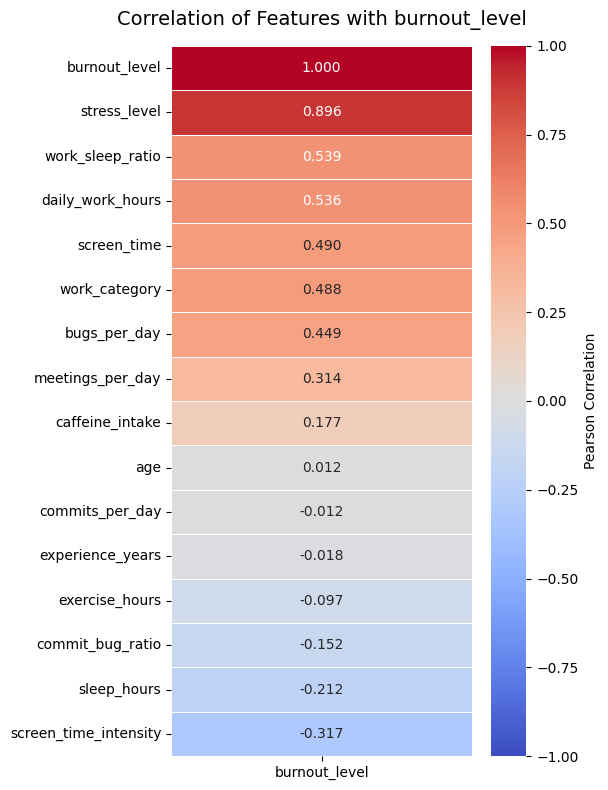

In [5]:
# Display data structure
print("[DATA STRUCTURE]")
dtype_df = df_raw.dtypes.reset_index()
dtype_df.columns = ['Column', 'Type']
print(dtype_df.to_string(index=False))

# Target distribution
print(f"\n[TARGET DISTRIBUTION] '{TARGET_COLUMN}':")
target_dist = df_raw[TARGET_COLUMN].value_counts().sort_index()
for idx, count in target_dist.items():
    label = CLASS_LABELS.get(idx, f"Class {idx}")
    percentage = (count / len(df_raw)) * 100
    print(f"  {label:<10}: {count:>5} ({percentage:>5.2f}%)")

# Visualize target distribution
plt.figure(figsize=(8, 5))
sns.barplot(
    x=[CLASS_LABELS[i] for i in target_dist.index],
    y=target_dist.values,
    palette='viridis'
)

plt.title('Burnout Level Distribution', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Descriptive statistics
print(f"\n[DESCRIPTIVE STATISTICS]")
print(df_raw.describe().T)
print()

# Correlation analysis
numeric_cols = [col for col in df_raw.columns if df_raw[col].dtype != 'object']
correlations = df_raw[numeric_cols].corr()[[TARGET_COLUMN]].sort_values(by=TARGET_COLUMN, ascending=False)
plt.figure(figsize=(6, 8))
sns.heatmap(
    correlations,
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'}
)

plt.title(f'Correlation of Features with {TARGET_COLUMN}', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 6. Data Preprocessing


In [6]:
# Handle outliers
print("[INFO] Handling outliers...")
if OUTLIER_COL in df_raw.columns:
    clip_value = df_raw[OUTLIER_COL].quantile(OUTLIER_CLIP_Q)
    df_raw[OUTLIER_COL] = df_raw[OUTLIER_COL].clip(upper=clip_value)
    print(f"  Clipped '{OUTLIER_COL}' at {OUTLIER_CLIP_Q} quantile: {clip_value:.4f}")

# Separate features and target
X = df_raw.drop(columns=[TARGET_COLUMN])
y = df_raw[TARGET_COLUMN].values

print(f"\n[PREPROCESSING COMPLETE]")
print(f"  Features shape: {X.shape}")
print(f"  Target shape: {y.shape}")
print(f"  Feature columns: {list(X.columns)}")


[INFO] Handling outliers...
  Clipped 'commit_bug_ratio' at 0.99 quantile: 220.0000

[PREPROCESSING COMPLETE]
  Features shape: (7000, 15)
  Target shape: (7000,)
  Feature columns: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level', 'work_sleep_ratio', 'screen_time_intensity', 'commit_bug_ratio', 'work_category']


# 7. Dataset Splitting


In [7]:
# Split into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("[INFO] Dataset split completed")
print_split_summary(X_train, X_val, X_test)

# Verify class distribution
print("\n[CLASS DISTRIBUTION]")
for split_name, split_y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    unique, counts = np.unique(split_y, return_counts=True)
    dist_str = ", ".join([f"{CLASS_LABELS[u]}: {c}" for u, c in zip(unique, counts)])
    print(f"  {split_name:<10}: {dist_str}")


[INFO] Dataset split completed

  Split             Samples   Percentage
  --------------------------------------
  Train                5600        80.0%
  Validation            700        10.0%
  Test                  700        10.0%
  --------------------------------------
  Total                7000       100.0%

[CLASS DISTRIBUTION]
  Train     : Low: 1275, Medium: 2899, High: 1426
  Val       : Low: 159, Medium: 363, High: 178
  Test      : Low: 159, Medium: 363, High: 178


# 8. Feature Scaling


In [8]:
# Use RobustScaler for outlier resistance
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("[INFO] Feature scaling completed using RobustScaler")
print(f"      Train scaled shape : {X_train_scaled.shape}")
print(f"      Val scaled shape   : {X_val_scaled.shape}")
print(f"      Test scaled shape  : {X_test_scaled.shape}")

# Save scaler
scaler_path = MODEL_SAVE_DIR / "scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"\n[OK] Scaler saved to: {scaler_path}")


[INFO] Feature scaling completed using RobustScaler
      Train scaled shape : (5600, 15)
      Val scaled shape   : (700, 15)
      Test scaled shape  : (700, 15)

[OK] Scaler saved to: models/scaler.pkl


# 9. Class Imbalance Handling


[INFO] Applying SMOTE to handle class imbalance...

[SMOTE RESULTS]
  Original train size: 5600
  Balanced train size: 8697


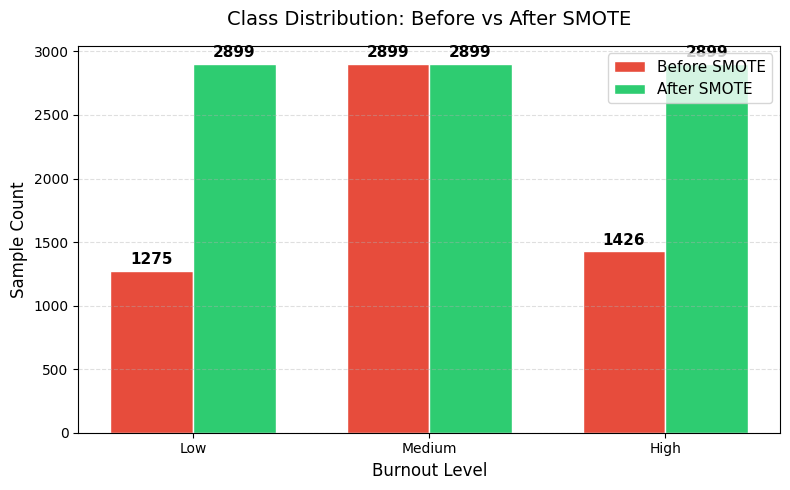


[CLASS WEIGHTS]
  Class 0 (Low): 1.0000
  Class 1 (Medium): 1.0000
  Class 2 (High): 1.0000


In [9]:
print("[INFO] Applying SMOTE to handle class imbalance...")

# Simpan distribusi SEBELUM SMOTE
unique_before, counts_before = np.unique(y_train, return_counts=True)

smote = SMOTE(random_state=RANDOM_SEED)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Simpan distribusi SESUDAH SMOTE
unique_after, counts_after = np.unique(y_train_balanced, return_counts=True)

print(f"\n[SMOTE RESULTS]")
print(f"  Original train size: {len(X_train_scaled)}")
print(f"  Balanced train size: {len(X_train_balanced)}")

labels = [CLASS_LABELS[u] for u in unique_before]
x_pos  = np.arange(len(labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x_pos - bar_width/2, counts_before, bar_width, label='Before SMOTE', color='#e74c3c', edgecolor='white')
bars2 = ax.bar(x_pos + bar_width/2, counts_after,  bar_width, label='After SMOTE',  color='#2ecc71', edgecolor='white')

# Tambahkan angka di atas setiap bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Class Distribution: Before vs After SMOTE', fontsize=14, pad=15)
ax.set_xlabel('Burnout Level', fontsize=12)
ax.set_ylabel('Sample Count', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Compute class weights for loss function
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_balanced),
    y=y_train_balanced
)
class_weights_list = class_weights.tolist()

print("\n[CLASS WEIGHTS]")
for i, weight in enumerate(class_weights_list):
    print(f"  Class {i} ({CLASS_LABELS[i]}): {weight:.4f}")

# 10. Input Pipeline — tf.data


In [10]:
# Convert labels to categorical
y_train_cat = tf.keras.utils.to_categorical(y_train_balanced, NUM_CLASSES)
y_val_cat = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test_cat = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

# Create TensorFlow datasets with optimization
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_balanced, y_train_cat))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_scaled, y_val_cat))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test_cat))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

INPUT_SIZE = X_train_balanced.shape[1]

print("[INFO] tf.data pipeline created")
print(f"      Input size    : {INPUT_SIZE}")
print(f"      Train batches : {len(train_dataset)}")
print(f"      Val batches   : {len(val_dataset)}")
print(f"      Test batches  : {len(test_dataset)}")


[INFO] tf.data pipeline created
      Input size    : 15
      Train batches : 272
      Val batches   : 22
      Test batches  : 22


# 11. Custom Loss Function

In [11]:
class WeightedCategoricalCrossentropy(tf.keras.losses.Loss):
    """
    Custom Loss: cross-entropy dengan bobot per kelas.
    """
    def __init__(self, class_weights: list = None, label_smoothing: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        weights = class_weights if class_weights is not None else [1.0, 1.0, 1.0]
        self.class_weights = tf.constant(weights, dtype=tf.float32)
        self.label_smoothing = tf.constant(label_smoothing, dtype=tf.float32)

    def call(self, y_true, y_pred):
        y_true      = tf.cast(y_true, tf.int32)
        y_pred      = tf.clip_by_value(y_pred, 1e-7, 1.0)
        y_onehot    = tf.one_hot(y_true, depth=NUM_CLASSES)

        y_smoothed = y_onehot * (1.0 - self.label_smoothing) + (self.label_smoothing / NUM_CLASSES)

        ce          = -tf.reduce_sum(y_smoothed * tf.math.log(y_pred), axis=-1)
        sample_w    = tf.gather(self.class_weights, y_true)
        return tf.reduce_mean(ce * sample_w)

    def get_config(self):
        config = super().get_config()
        config.update({
            "class_weights": self.class_weights.numpy().tolist(),
            "label_smoothing": self.label_smoothing.numpy().item()
        })
        return config

print("[OK] Custom Loss berhasil diimplementasikan.")


[OK] Custom Loss berhasil diimplementasikan.


# 12. Custom Callback

In [12]:
class BurnAwayEarlyStopping(tf.keras.callbacks.Callback):
    """
    Custom Callback: hentikan training saat target akurasi tercapai.
    Menyimpan model terbaik berdasarkan val_loss.
    """
    def __init__(self, target_accuracy: float = 0.85, save_path: str = str(MODEL_BEST_PATH), patience: int = 5):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.save_path       = save_path
        self.best_val_loss   = float("inf")
        self.best_epoch      = -1
        self.patience        = patience
        self.wait            = 0
        self._should_stop    = False # Flag untuk stop custom loop

    def on_epoch_end(self, epoch, logs=None):
        logs     = logs or {}
        val_acc  = logs.get("val_accuracy", 0.0)
        val_loss = logs.get("val_loss", float("inf"))

        # Variabel untuk menampung pesan agar bisa dicetak di sebelah tabel
        msg = ""

        if epoch >= MIN_EPOCHS_BEFORE_SAVE and val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_epoch   = epoch + 1
            self.wait = 0
            self.model.save(self.save_path)
            msg += f"  [CHECKPOINT] Model Tersimpan"
        else:
            self.wait += 1

        if val_acc >= self.target_accuracy:
            msg += f"  [TARGET ACHIEVED]"

        if self.wait >= self.patience and epoch >= MIN_EPOCHS_BEFORE_SAVE:
            msg += f"  [EARLY STOP] (Best: Ep {self.best_epoch})"
            self.model.stop_training = True
            self._should_stop = True # Pastikan flag tersetting

        return msg

print("[OK] Custom Callback berhasil diimplementasikan.")

[OK] Custom Callback berhasil diimplementasikan.


# 13. Custom Layer

In [13]:
class BurnoutAttentionLayer(tf.keras.layers.Layer):
    """Custom Layer: soft attention berbasis fitur tabular."""
    def __init__(self, units: int = 32, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform", trainable=True, name="attention_kernel")
        self.b = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True, name="attention_bias")
        self.attention_v = self.add_weight(shape=(self.units, 1), initializer="glorot_uniform", trainable=True, name="attention_v")

    def call(self, inputs):
        score = tf.nn.tanh(tf.matmul(inputs, self.w) + self.b)
        attention_weights = tf.nn.softmax(tf.matmul(score, self.attention_v), axis=-1)
        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

print("[OK] Custom Layer berhasil diimplementasikan.")


[OK] Custom Layer berhasil diimplementasikan.


# 14. Model Architecture

In [14]:
def build_burnaway_model(input_shape: int, num_classes: int) -> Model:
    """Model Klasifikasi dengan BurnoutAttentionLayer dan Residual Connections."""
    inputs = layers.Input(shape=(input_shape,), name='input_features')

    x = BurnoutAttentionLayer(units=ATTENTION_UNITS, name="attention_layer")(inputs)

    x1 = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation('swish')(x1)

    x2 = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x1)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Activation('swish')(x2)
    x = layers.Add()([x1, x2])
    x = layers.Dropout(0.15)(x)

    shared = layers.Dense(64, activation='swish')(x)
    shared = layers.BatchNormalization()(shared)
    shared = layers.Dropout(0.1)(shared)

    clf = layers.Dense(32, activation='swish')(shared)
    clf = layers.Dense(16, activation='swish')(clf)
    classification_output = layers.Dense(num_classes, activation="softmax", name='classification_output')(clf)

    model = Model(inputs=inputs, outputs=classification_output, name='BurnAway_Classification_Model')
    return model

model = build_burnaway_model(INPUT_SIZE, NUM_CLASSES)
model.summary()


Model: "BurnAway_Classification_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 15)        │      1,088 │ input_features[0… │
│ (BurnoutAttentionL… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      2,048 │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ activation[0][0], │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 3)         │         51 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,843 (124.39 KB)

 Trainable params: 31,203 (121.89 KB)

 Non-trainable params: 640 (2.50 KB)

# 15. K-Fold Cross-Validation


In [15]:
loss_fn_clf = WeightedCategoricalCrossentropy(
    class_weights=class_weights_list,
    label_smoothing=LABEL_SMOOTHING
)

def run_kfold_validation(x_data: np.ndarray, y_clf: np.ndarray, n_splits: int = 5):
    """Executes K-Fold Cross-Validation for the classification model."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)

    print(f"[INFO] Starting {n_splits}-Fold Cross-Validation...\n")

    fold_scores = []

    # y_clf here is expected to be sparse labels (e.g., y_train).
    # StratifiedKFold expects sparse labels for splitting.
    y_labels = y_clf # y_clf should already be sparse labels

    for fold, (train_idx, val_idx) in enumerate(skf.split(x_data, y_labels)):
        x_train_fold, x_val_fold = x_data[train_idx], x_data[val_idx]
        y_train_fold, y_val_fold = y_clf[train_idx], y_clf[val_idx]

        # SMOTE pada data training saja
        smote = SMOTE(random_state=RANDOM_SEED)
        x_resampled, y_resampled = smote.fit_resample(x_train_fold, y_train_fold)

        # Create datasets with sparse labels, as WeightedCategoricalCrossentropy expects sparse y_true
        train_ds = create_tf_dataset(x_resampled, y_resampled, is_training=True)
        val_ds   = create_tf_dataset(x_val_fold, y_val_fold, is_training=False)

        # 1. Inisialisasi model baru untuk setiap fold agar tidak menggunakan bobot fold sebelumnya!
        fold_model = build_burnaway_model(INPUT_SIZE, NUM_CLASSES)

        # 2. Compile model
        fold_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss=loss_fn_clf,
            metrics=['accuracy']
        )

        # 3. Lakukan training
        history = fold_model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=10,
            verbose=0
        )

        # 4. Ambil dan simpan akurasi validasi terbaik/terakhir dari fold ini
        val_acc = max(history.history['val_accuracy'])
        fold_scores.append(val_acc)

        # Cetak output 1 baris yang rapi untuk setiap fold
        print(f" Fold {fold+1}/{n_splits} | Train: {len(x_resampled):<4} | Val: {len(x_val_fold):<4} | Val. Accuracy: {val_acc:.4f}")

    print("-" * 65) # Garis pemisah bawah
    print(f"[OK] K-Fold Validation Finished!")
    print(f"Average Validation Accuracy: {np.mean(fold_scores):.4f} \u00b1 {np.std(fold_scores):.4f}\n")

    return fold_scores

# Call run_kfold_validation with original scaled training features and their sparse labels
fold_scores = run_kfold_validation(X_train_scaled, y_train, n_splits=5)

[INFO] Starting 5-Fold Cross-Validation...

 Fold 1/5 | Train: 6960 | Val: 1120 | Val. Accuracy: 0.6982
 Fold 2/5 | Train: 6957 | Val: 1120 | Val. Accuracy: 0.7161
 Fold 3/5 | Train: 6957 | Val: 1120 | Val. Accuracy: 0.6839
 Fold 4/5 | Train: 6957 | Val: 1120 | Val. Accuracy: 0.7804
 Fold 5/5 | Train: 6957 | Val: 1120 | Val. Accuracy: 0.7625
-----------------------------------------------------------------
[OK] K-Fold Validation Finished!
Average Validation Accuracy: 0.7282 ± 0.0372



# 16. Optimizer & Training Configuration


In [16]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=LEARNING_RATE,
    first_decay_steps=1000,
    t_mul=2.0,
    m_mul=0.9,
    alpha=1e-5
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=GRAD_CLIP)

loss_fn_clf = WeightedCategoricalCrossentropy(
    class_weights=class_weights_list,
    label_smoothing=LABEL_SMOOTHING
)

train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
val_acc_metric   = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

print(f"[INFO] Konfigurasi Optimizer & Loss selesai.")
print(f"       Initial LR: {LEARNING_RATE}")
print(f"       Loss: WeightedCategoricalCrossentropy")

[INFO] Konfigurasi Optimizer & Loss selesai.
       Initial LR: 0.001
       Loss: WeightedCategoricalCrossentropy


# 17. TensorBoard Monitoring

In [17]:
tb_writer = tf.summary.create_file_writer(str(LOG_DIR))

def log_to_tensorboard(epoch: int, metrics: dict) -> None:
    """Menulis metrik training ke TensorBoard log directory."""
    with tb_writer.as_default():
        for name, value in metrics.items():
            tf.summary.scalar(name, data=value, step=epoch)
        tb_writer.flush()

print(f'[INFO] TensorBoard log directory : {LOG_DIR}')
print(f'[INFO] Jalankan perintah berikut untuk membuka TensorBoard:')
print(f'       %tensorboard --logdir {LOG_DIR}')

# Untuk Google Colab — aktifkan TensorBoard extension
try:
    from google.colab import output
    output.serve_kernel_port_as_iframe(6006)
    print('[INFO] TensorBoard iframe aktif di Colab.')
except Exception:
    print('[INFO] Mode lokal: Jalankan tensorboard --logdir dari terminal.')

[INFO] TensorBoard log directory : logs/fit/20260521-160151
[INFO] Jalankan perintah berikut untuk membuka TensorBoard:
       %tensorboard --logdir logs/fit/20260521-160151


<IPython.core.display.Javascript object>

[INFO] TensorBoard iframe aktif di Colab.


# 18. Custom Training Loop


In [18]:
@tf.function
def train_step(x, y_clf):
    with tf.GradientTape() as tape:
        clf_probs = model(x, training=True)
        y_clf_sparse = tf.argmax(y_clf, axis=-1)
        loss_clf = loss_fn_clf(y_clf_sparse, clf_probs)

    gradients = tape.gradient(loss_clf, model.trainable_variables)
    gradients, _ = tf.clip_by_global_norm(gradients, GRAD_CLIP)

    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    train_acc_metric.update_state(y_clf_sparse, clf_probs)

    return loss_clf

@tf.function
def val_step(x, y_clf):
    clf_probs = model(x, training=False)
    y_clf_sparse = tf.argmax(y_clf, axis=-1)
    loss_clf = loss_fn_clf(y_clf_sparse, clf_probs)
    val_acc_metric.update_state(y_clf_sparse, clf_probs)
    return loss_clf

print("[OK] Optimized Train Step siap digunakan.")

# The actual training loop execution
history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
early_stopping = BurnAwayEarlyStopping(target_accuracy=TARGET_ACCURACY, save_path=str(MODEL_BEST_PATH))
early_stopping.set_model(model)

print(f"\n{'Epoch':<10} | {'Train Loss':<12} | {'Train Acc':<10} | {'Val Loss':<10} | {'Val Acc':<10}")
print("-" * 63)

for epoch in range(EPOCHS):
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()

    total_train_loss = 0.0
    batches = 0
    for x_batch, y_batch in train_dataset:
        loss = train_step(x_batch, y_batch)
        total_train_loss += loss
        batches += 1
    avg_train_loss = total_train_loss / batches

    total_val_loss = 0.0
    val_batches = 0
    for x_val, y_val in val_dataset:
        v_loss = val_step(x_val, y_val)
        total_val_loss += v_loss
        val_batches += 1
    avg_val_loss = total_val_loss / val_batches

    t_acc = train_acc_metric.result().numpy()
    v_acc = val_acc_metric.result().numpy()

    history['loss'].append(float(avg_train_loss))
    history['val_loss'].append(float(avg_val_loss))
    history['accuracy'].append(float(t_acc))
    history['val_accuracy'].append(float(v_acc))

    # Eksekusi callback terlebih dahulu untuk mendapatkan string pesan (msg)
    logs = {'val_loss': avg_val_loss, 'val_accuracy': v_acc}
    msg = early_stopping.on_epoch_end(epoch, logs)

    # Cetak semuanya dalam satu baris!
    epoch_str = f"{epoch+1:02d}/{EPOCHS:02d}"
    print(f"{epoch_str:<10} | {avg_train_loss:<12.4f} | {t_acc:<10.4f} | {avg_val_loss:<10.4f} | {v_acc:<10.4f}{msg}")

    log_to_tensorboard(epoch, {'loss': avg_train_loss, 'accuracy': t_acc, 'val_loss': avg_val_loss, 'val_accuracy': v_acc})

    # Hentikan proses secara paksa jika flag Early Stop menyala
    if early_stopping._should_stop:
        break

[OK] Optimized Train Step siap digunakan.

Epoch      | Train Loss   | Train Acc  | Val Loss   | Val Acc   
---------------------------------------------------------------
01/30      | 0.5755       | 0.8022     | 1.1781     | 0.4829    
02/30      | 0.6848       | 0.7566     | 0.7823     | 0.5943    
03/30      | 0.7311       | 0.6915     | 0.5747     | 0.8343    
04/30      | 0.6228       | 0.7766     | 1.0885     | 0.4986    
05/30      | 0.6015       | 0.7934     | 1.1947     | 0.5557    
06/30      | 0.6334       | 0.7752     | 0.8884     | 0.5571    
07/30      | 0.6785       | 0.7308     | 0.6900     | 0.6714    
08/30      | 0.6690       | 0.7345     | 0.5675     | 0.7857    
09/30      | 0.6796       | 0.7213     | 0.5079     | 0.8671      [TARGET ACHIEVED]
10/30      | 0.6699       | 0.7255     | 0.4518     | 0.9514      [TARGET ACHIEVED]
11/30      | 0.6506       | 0.7444     | 0.4425     | 0.9529      [CHECKPOINT] Model Tersimpan  [TARGET ACHIEVED]
12/30      | 0.5086       

# 19. Training History Visualization

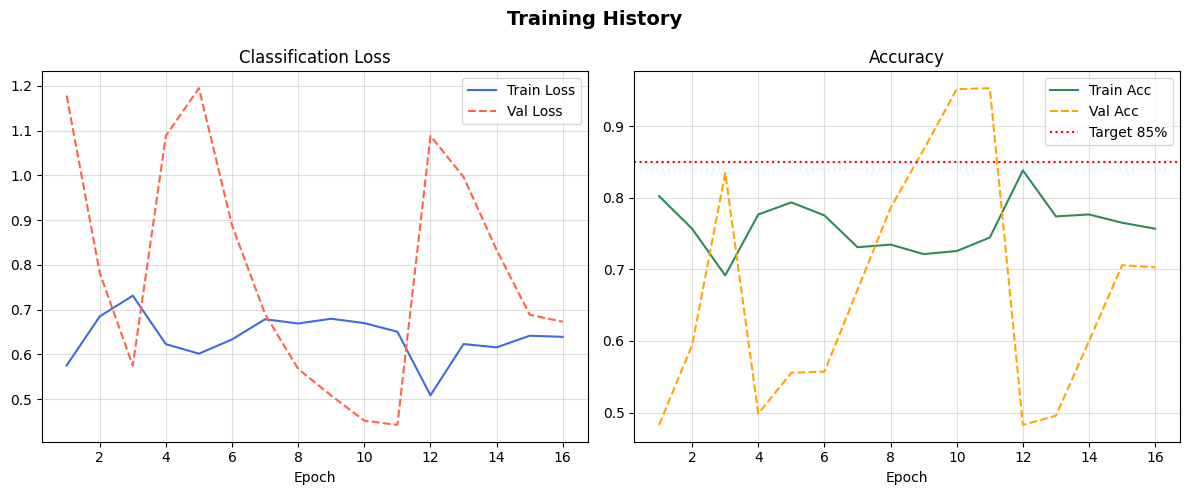


[BEST]  11 | Val Acc: 0.9529
[STATUS] Accuracy: 95.29% [ACHIEVED]


In [19]:
def plot_training_history(history: dict) -> None:
    """Memvisualisasikan kurva training dan validasi."""
    epochs_range = range(1, len(history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Training History', fontsize=14, fontweight='bold')

    axes[0].plot(epochs_range, history['loss'],     label='Train Loss',  color='royalblue')
    axes[0].plot(epochs_range, history['val_loss'], label='Val Loss',    color='tomato', linestyle='--')
    axes[0].set_title('Classification Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.4)

    axes[1].plot(epochs_range, history['accuracy'],     label='Train Acc', color='seagreen')
    axes[1].plot(epochs_range, history['val_accuracy'], label='Val Acc',   color='orange', linestyle='--')
    axes[1].axhline(TARGET_ACCURACY, color='red', linestyle=':', label=f'Target {TARGET_ACCURACY*100:.0f}%')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

best_epoch = int(np.argmax(history['val_accuracy'])) + 1
best_acc   = max(history['val_accuracy'])
print(f'\n[BEST]  {best_epoch} | Val Acc: {best_acc:.4f}')
print(f'[STATUS] {check_target_achieved(best_acc)}')

model = tf.keras.models.load_model(str(MODEL_BEST_PATH), custom_objects={"BurnoutAttentionLayer": BurnoutAttentionLayer, "WeightedCategoricalCrossentropy": WeightedCategoricalCrossentropy})


# 20. Final Evaluation


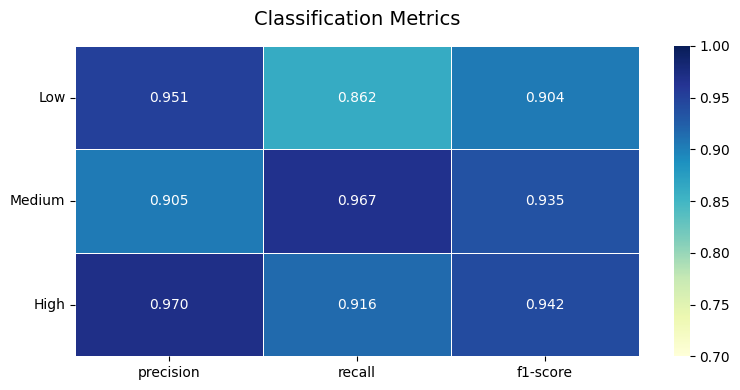

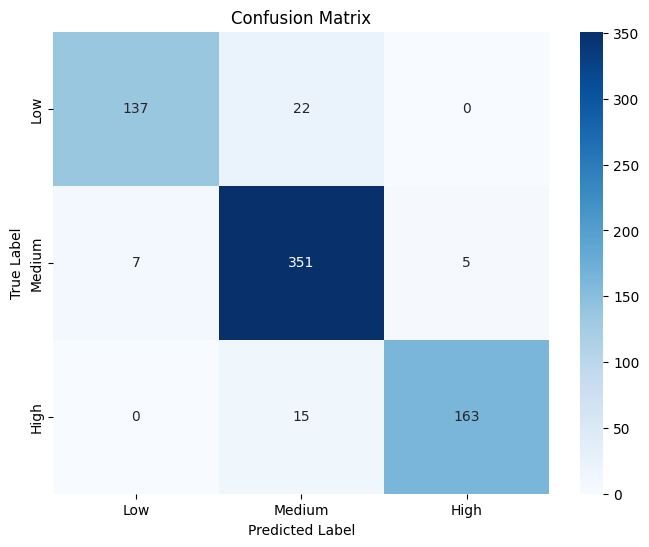


[SUMMARY] Test Acc: 93.00%
[STATUS]  Accuracy: 93.00% [ACHIEVED]


In [20]:
def evaluate_final_model(model, test_dataset, class_labels):
    """Evaluasi komprehensif pada data tes: Klasifikasi."""
    all_y_clf = []
    all_pred_clf = []

    for x, y_clf in test_dataset:
        clf_probs = model(x, training=False)
        pred_clf = tf.argmax(clf_probs, axis=1)

        all_y_clf.extend(tf.argmax(y_clf, axis=1).numpy())
        all_pred_clf.extend(pred_clf.numpy())

        report_dict = classification_report(
        all_y_clf, all_pred_clf,
        target_names=list(class_labels.values()),
        output_dict=True
    )

    classes = list(class_labels.values())
    metrics_df = pd.DataFrame(report_dict)[classes].T

    plt.figure(figsize=(8, 4))
    sns.heatmap(
        metrics_df[['precision', 'recall', 'f1-score']],
        annot=True,
        cmap='YlGnBu',
        fmt='.3f',
        vmin=0.7, vmax=1.0,
        linewidths=0.5
    )

    plt.title('Classification Metrics', fontsize=14, pad=15)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(all_y_clf, all_pred_clf)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels.values(), yticklabels=class_labels.values())
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    test_acc = np.mean(np.array(all_y_clf) == np.array(all_pred_clf))
    print(f"\n[SUMMARY] Test Acc: {test_acc:.2%}")
    print(f"[STATUS]  {check_target_achieved(test_acc)}")

evaluate_final_model(model, test_dataset, CLASS_LABELS)

# 21. Inference Pipeline

In [21]:
FEATURE_COLS = X.columns.tolist()

def predict_burnout(raw_input: dict, inference_model=None, inference_scaler=None) -> dict:
    inf_model  = inference_model  or model
    inf_scaler = inference_scaler or scaler

    missing = [c for c in FEATURE_COLS if c not in raw_input]
    if missing:
        raise ValueError(f'[ERROR] Fitur berikut tidak ditemukan dalam input: {missing}')

    x_raw  = np.array([[raw_input[c] for c in FEATURE_COLS]], dtype=np.float32)

    cbr_idx = FEATURE_COLS.index('commit_bug_ratio') if 'commit_bug_ratio' in FEATURE_COLS else -1
    if cbr_idx >= 0:
        x_raw[0, cbr_idx] = min(x_raw[0, cbr_idx], 220.0)

    x_scaled = inf_scaler.transform(x_raw).astype(np.float32)

    clf_probs = inf_model.predict(x_scaled, verbose=0)
    probs          = clf_probs[0]
    predicted_cls  = int(np.argmax(probs))

    result = {
        'label':          CLASS_LABELS[predicted_cls],
        'confidence':     float(probs[predicted_cls]),
        'class_probs':    {CLASS_LABELS[i]: float(p) for i, p in enumerate(probs)},
    }

    return result

sample_input = {
    'age': 28.0, 'experience_years': 3.0, 'daily_work_hours': 11.5,
    'sleep_hours': 5.2, 'caffeine_intake': 5.0, 'bugs_per_day': 14.0,
    'commits_per_day': 7.0, 'meetings_per_day': 6.0, 'screen_time': 13.5,
    'exercise_hours': 0.3, 'work_sleep_ratio': 2.21,
    'screen_time_intensity': 1.17, 'commit_bug_ratio': 0.5, 'work_category': 1.0,
    'stress_level': 5.0
}

prediction = predict_burnout(sample_input, inference_model=model, inference_scaler=scaler)
print(f'Label          : {prediction["label"]}')
print(f'Confidence     : {prediction["confidence"]:.2%}')
print(f'Class Probs    : { {k: f"{v:.2%}" for k, v in prediction["class_probs"].items()} }')

Label          : Low
Confidence     : 80.77%
Class Probs    : {'Low': '80.77%', 'Medium': '14.98%', 'High': '4.25%'}


# 22. Generative AI Advisory Layer

In [22]:
def build_advisory_prompt(prediction_result: dict, user_context: dict = None) -> str:
    label       = prediction_result['label']
    confidence  = prediction_result['confidence']
    class_probs = prediction_result['class_probs']

    prompt = (
        f"Kamu adalah asisten kesehatan mental profesional untuk developer perangkat lunak.\n"
        f"Berdasarkan analisis AI, developer ini terdeteksi berada di level burnout: **{label}** "
        f"(confidence: {confidence:.1%}).\n"
        f"Distribusi probabilitas kelas: {class_probs}.\n\n"
        f"Berikan 5 rekomendasi konkret dan personal dalam bahasa Indonesia yang:\n"
        f"1. Spesifik untuk level burnout '{label}'\n"
        f"2. Dapat langsung diterapkan oleh developer\n"
        f"3. Mencakup aspek: manajemen waktu, kesehatan fisik, dan produktivitas\n"
        f"Tutup dengan kalimat motivasi singkat."
    )

    return prompt

def get_burnout_advice_sdk(prompt: str) -> str:
    try:
        client   = genai.Client(api_key=GEMINI_API_KEY)
        response = client.models.generate_content(
            model=GEMINI_MODEL,
            contents=prompt,
        )

        return response.text
    except Exception as e:
        return f'[SDK ERROR] {str(e)}'

def get_burnout_advice_rest(prompt: str) -> str:
    if not GEMINI_API_KEY:
        return '[INFO] GEMINI_API_KEY tidak ditemukan. Set environment variable GEMINI_API_KEY.'

    url     = f'{GEMINI_BASE_URL}/{GEMINI_MODEL}:generateContent?key={GEMINI_API_KEY}'
    payload = {
        'contents': [{'parts': [{'text': prompt}]}],
        'generationConfig': {'temperature': 0.7, 'maxOutputTokens': 1024},
    }
    try:
        resp = requests.post(url, json=payload, timeout=30)
        resp.raise_for_status()
        return resp.json()['candidates'][0]['content']['parts'][0]['text']
    except Exception as e:
        return f'[REST ERROR] {str(e)}'

def get_burnout_advice_groq(prompt: str) -> str:
    if not GROQ_API_KEY:
        raise ValueError("GROQ_API_KEY tidak ditemukan.")

    url = 'https://api.groq.com/openai/v1/chat/completions'
    headers = {
        'Authorization': f'Bearer {GROQ_API_KEY}',
        'Content-Type': 'application/json'
    }
    payload = {
        'model': 'llama3-8b-8192',
        'messages': [{'role': 'user', 'content': prompt}],
        'temperature': 0.7,
        'max_tokens': 1024
    }

    resp = requests.post(url, headers=headers, json=payload, timeout=30)
    resp.raise_for_status()
    return resp.json()['choices'][0]['message']['content']

def get_burnout_advice(prediction_result: dict, primary: str = 'gemini') -> tuple:
    prompt = build_advisory_prompt(prediction_result)

    def call_gemini():
        if GENAI_SDK_AVAILABLE and GEMINI_API_KEY:
            result = get_burnout_advice_sdk(prompt)
            route = 'Gemini (SDK)'
        elif GEMINI_API_KEY:
            result = get_burnout_advice_rest(prompt)
            route = 'Gemini (REST)'
        else:
            raise ValueError("GEMINI_API_KEY tidak tersedia.")

        if result.startswith('[SDK ERROR]') or result.startswith('[REST ERROR]'):
            raise RuntimeError(result)
        return result, route

    def call_groq():
        result = get_burnout_advice_groq(prompt)
        return result, 'Groq (REST)'

    try:
        if primary == 'gemini':
            advice, route = call_gemini()
        else:
            advice, route = call_groq()

    except Exception as e:
        print(f"[GENAI WARNING] Akses ke API {primary.upper()} gagal ({str(e)}). Menggunakan fallback...")
        try:
            if primary == 'gemini':
                advice, route = call_groq()
            else:
                advice, route = call_gemini()
        except Exception as fallback_error:
            fallback_api = 'GROQ' if primary == 'gemini' else 'GEMINI'
            print(f"[GENAI WARNING] Akses ke API {fallback_api} juga gagal ({str(fallback_error)}). Beralih ke Offline Mode...")

            route = "Offline (Rule-Based)"
            label = prediction_result.get('label', 'low').lower()

            if label == "high":
                advice = (
                    "Tingkat burnout Anda TINGGI.\n"
                    "1. Segera jadwalkan waktu istirahat atau cuti panjang untuk memulihkan energi.\n"
                    "2. Diskusikan pendelegasian tugas dengan manajer Anda, jangan menanggung semuanya sendiri.\n"
                    "3. Jangan ragu untuk mencari bantuan profesional (psikolog/konselor) jika merasa kewalahan.\n"
                    "4. Batasi jam kerja secara ketat dan hindari membuka pekerjaan di luar jam kantor.\n"
                    "5. Lakukan aktivitas fisik ringan setiap hari, meskipun hanya sekadar jalan kaki santai.\n\n"
                    "Kesehatan mentalmu jauh lebih berharga daripada tenggat waktu mana pun. Istirahatlah sejenak!"
                )
            elif label == "medium":
                advice = (
                    "Tingkat burnout Anda SEDANG.\n"
                    "1. Mulai rapikan manajemen waktu dan prioritas harian menggunakan metode seperti Pomodoro atau Timeblocking.\n"
                    "2. Pastikan tidak melakukan lembur yang tidak perlu. Ketahui batasan energimu.\n"
                    "3. Luangkan akhir pekan sepenuhnya untuk hobi dan kegiatan yang merilekskan pikiran.\n"
                    "4. Sempatkan untuk melakukan peregangan kecil dan istirahat mata (aturan 20-20-20) selama jam kerja.\n"
                    "5. Jangan ragu untuk mengatakan 'tidak' pada tugas tambahan jika kapasitasmu sudah penuh.\n\n"
                    "Cegah burnout sebelum semakin parah dengan mulai mengatur keseimbangan hidup."
                )
            else:
                advice = (
                    "Tingkat burnout Anda RENDAH.\n"
                    "1. Pertahankan rutinitas kerja dan work-life balance Anda saat ini.\n"
                    "2. Jaga pola makan, tidur, dan olahraga yang teratur untuk memastikan energi selalu optimal.\n"
                    "3. Tetap waspada jika beban kerja tiba-tiba meningkat tajam dan kenali tanda-tanda awal stres.\n"
                    "4. Lanjutkan praktik manajemen waktu yang sudah berjalan baik.\n"
                    "5. Jangan lupa untuk sesekali memberikan apresiasi kepada diri sendiri atas pekerjaan yang telah diselesaikan.\n\n"
                    "Bagus sekali! Pertahankan energimu dan teruslah berkarya secara sehat."
                )

    return advice, route

advice, route = get_burnout_advice(prediction)

print(f'\nRECOMMENDATION FOR {prediction["label"].upper()} BURNOUT:')
print(f'[GENAI] Routing: {route}')
print("-" * 50)
print(advice)

[GENAI WARNING] Akses ke API GEMINI gagal (GEMINI_API_KEY tidak tersedia.). Menggunakan fallback...
[GENAI WARNING] Akses ke API GROQ juga gagal (GROQ_API_KEY tidak ditemukan.). Beralih ke Offline Mode...

RECOMMENDATION FOR LOW BURNOUT:
[GENAI] Routing: Offline (Rule-Based)
--------------------------------------------------
Tingkat burnout Anda RENDAH.
1. Pertahankan rutinitas kerja dan work-life balance Anda saat ini.
2. Jaga pola makan, tidur, dan olahraga yang teratur untuk memastikan energi selalu optimal.
3. Tetap waspada jika beban kerja tiba-tiba meningkat tajam dan kenali tanda-tanda awal stres.
4. Lanjutkan praktik manajemen waktu yang sudah berjalan baik.
5. Jangan lupa untuk sesekali memberikan apresiasi kepada diri sendiri atas pekerjaan yang telah diselesaikan.

Bagus sekali! Pertahankan energimu dan teruslah berkarya secara sehat.


# 23. Artifact Serialization & Export

In [23]:
def save_model_artifacts(final_model, fit_scaler, feature_columns: list, class_map: dict) -> None:
    final_model.save(str(MODEL_FINAL_PATH))
    print(f'  [OK] Model final          → {MODEL_FINAL_PATH}')

    scaler_path = MODEL_SAVE_DIR / 'scaler.joblib'
    joblib.dump(fit_scaler, str(scaler_path))
    print(f'  [OK] RobustScaler         → {scaler_path}')

    feat_path = API_DIR / 'feature_cols.json'
    with open(feat_path, 'w', encoding='utf-8') as fp:
        _json.dump(feature_columns, fp, indent=2)
    print(f'  [OK] Feature columns      → {feat_path}')

    labels_path = API_DIR / 'class_labels.json'
    with open(labels_path, 'w', encoding='utf-8') as fp:
        _json.dump({str(k): v for k, v in class_map.items()}, fp, indent=2)
    print(f'  [OK] Class labels         → {labels_path}')

    config_path = API_DIR / 'pipeline_config.json'
    config_meta = {
        'num_features':    len(feature_columns),
        'num_classes':     NUM_CLASSES,
        'attention_units': ATTENTION_UNITS,
        'scaler_type':     'RobustScaler',
        'model_format':    '.keras',
        'target_accuracy': TARGET_ACCURACY,
    }
    with open(config_path, 'w', encoding='utf-8') as fp:
        _json.dump(config_meta, fp, indent=2)
    print(f'  [OK] Pipeline config      → {config_path}')

save_model_artifacts(model, scaler, FEATURE_COLS, CLASS_LABELS)

print()
for artifact in [MODEL_BEST_PATH, MODEL_FINAL_PATH,
                 MODEL_SAVE_DIR / 'scaler.joblib',
                 API_DIR / 'feature_cols.json',
                 API_DIR / 'class_labels.json',
                 API_DIR / 'pipeline_config.json']:
    exists = 'OK' if artifact.exists() else 'MISSING'
    print(f'  [{exists}] {artifact}')

print(f'\n[OK] Semua artifact berhasil diekspor.')
print(f'     Pipeline BurnAway siap untuk deployment via FastAPI!')


  [OK] Model final          → models/burnaway_model.keras
  [OK] RobustScaler         → models/scaler.joblib
  [OK] Feature columns      → api/feature_cols.json
  [OK] Class labels         → api/class_labels.json
  [OK] Pipeline config      → api/pipeline_config.json

  [OK] models/burnaway_model_best.keras
  [OK] models/burnaway_model.keras
  [OK] models/scaler.joblib
  [OK] api/feature_cols.json
  [OK] api/class_labels.json
  [OK] api/pipeline_config.json

[OK] Semua artifact berhasil diekspor.
     Pipeline BurnAway siap untuk deployment via FastAPI!
